# Empirical Validation of Theory

---

## Imports + Config + Dataloaders (Class-IL 2-task Split-MNIST)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from networks.BP_network import BP_network
from networks.EWC_network import EWC_network
from networks.EFC_network import EFC_network
from networks.Hess_network import Hess_network
from src.dataloaders import ClassILMNIST2Task
from src.utils import dotdict
from torch.utils.data import DataLoader, Subset

from tqdm import tqdm
import os
from sklearn.decomposition import PCA
import pickle

config = {
    "lr": 1e-4,
    "batch_size": 256,
    "epochs": 10,
    "mode": "di",  # or "di"
    "num_workers": 0,
    "loss_fn": "ce", # "mse"
    "optimizer": "Adam",
    "scheduler": "CosineAnnealingLR",
    "device": "cpu" if torch.cuda.is_available() else "cpu",
    "output_dir": "./outputs",
    "seed": 0,
    "target_lr": 2e-2, # needs to be < time_constant_ratio
    "alpha_di": 0.0017,
    "alpha_I": 0.0017,
    "tau": 0.032,
    "dt_di": 0.02,
    "psi_lr": 0.1,
    "alpha_psi": 0.0,
    "time_constant_ratio": 0.2, # this param can be merged with dt_di
    "tmax_di": 500,
    "k_p": 2.0,
    "eps": 1e-4, # there is an interplay between dt_di and eps and between target_lr and eps
    "save": False,
    "importance_ewc": 4.0, # ewc params
    "beta_efc": 1e-1, # efc params
    "flatten_imgs": True,
    "setting": "classIL2task", # domainIL, taskIL, classIL5task, classIL2task
    "peak": False, # saves the peak model based on cumulative accuracy and restores it after each task
    "layers": [784, 64, 64, 10],
    "num_tasks": 2,
    "classes_per_task": 5,
}

config = dotdict(config)
torch.set_default_device(config.device)
torch.manual_seed(config.seed)
np.random.seed(config.seed)

dataloader = ClassILMNIST2Task(config)

train_loader_A, test_loader_A = dataloader.get_dataloaders(task_id=0)
train_loader_B, test_loader_B = dataloader.get_dataloaders(task_id=1)

print(f"Task A: {len(train_loader_A.dataset)} train, {len(test_loader_A.dataset)} test")
print(f"Task B: {len(train_loader_B.dataset)} train, {len(test_loader_B.dataset)} test_only")

Task A: 30596 train, 5139 test
Task B: 29404 train, 10000 test_only


## Train Task A on BP_network

In [2]:
def evaluate(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0.0
    total_loss = 0.0
    task_set = set(range(task_classes[0], task_classes[1] + 1))
    criterion = net.loss_fn  # CE or MSE

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)
            true_labels = y.argmax(1)

            mask = torch.isin(true_labels, torch.tensor(list(task_set), device=config.device))
            if not mask.any():
                continue

            out = out[mask]
            y = y[mask]
            true_labels = true_labels[mask]

            start_idx = task_classes[0]
            pred_rel = out[:, start_idx:task_classes[1]+1].argmax(1)
            pred_abs = pred_rel + start_idx

            correct += (pred_abs == true_labels).sum().item()
            total += true_labels.size(0)
            total_loss += criterion(out[:, :task_classes[1]+1], y.argmax(1)).item() * true_labels.size(0)

    acc = correct / total if total else 0.0
    loss = total_loss / total if total else 0.0
    return acc, loss

In [3]:
bp_net_A = BP_network(config).to(config.device)
bp_net_A.task_id = 0
optimizer = optim.Adam(bp_net_A.parameters(), lr=1e-4)

bp_net_A.train()

for epoch in range(config.epochs):
    pbar = tqdm(total=len(train_loader_A), desc="BP (Task A)", unit="epoch", leave=True)
    for x, y in train_loader_A:
        x, y = x.to(config.device), y.to(config.device)

        optimizer.zero_grad()
        y_hat = bp_net_A(x)
        _ = bp_net_A.calculate_loss(y_hat, y.argmax(dim=1))
        bp_net_A.backward(y)          # BP-specific backward
        optimizer.step()

        pbar.update(1)

    # Train accuracy on Task A
    test_acc_A, _ = evaluate(bp_net_A, test_loader_A, task_id=0, task_classes=[0, 4])
    test_acc_B, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[5, 9])
    combined_test_acc, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[0, 9])  # all 10 classes are present

    # Update the progress-bar postfix
    pbar.set_postfix({
        "Test A" : f"{test_acc_A:.3f}",
        "Test B" : f"{test_acc_B:.3f}",
        "Comb"   : f"{combined_test_acc:.3f}"
    })

    pbar.close()

BP (Task A):   0%|          | 0/120 [00:00<?, ?epoch/s]

BP (Task A): 100%|██████████| 120/120 [00:01<00:00, 106.24epoch/s, Test A=0.979, Test B=0.238, Comb=0.503]


## Save Fisher^D + Hessian + theta^*

In [4]:
def copy_weights(src_net, dst_net):
    dst_net.load_state_dict(deepcopy(src_net.state_dict()))

# Create all networks
ewc_net = EWC_network(config)
efc_net = EFC_network(config)
bp_net = BP_network(config)
ehc_net = Hess_network(config)

ewc_net.task_id = 0
efc_net.task_id = 0
bp_net.task_id = 0
ehc_net.task_id = 0

ewc_net.complete_task(train_loader_A)
efc_net.complete_task(train_loader_A)
bp_net.complete_task(train_loader_A)
ehc_net.complete_task(train_loader_A)

fisher_A = ewc_net._fisher
hessian_A = ehc_net._hessian

# Save Fisher + Hessian + theta_star_flat after Task A
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

with open('outputs/fisher_hessian_theta_taskA_new.pkl', 'wb') as f:
    pickle.dump({'fisher': fisher_A, 'hessian': hessian_A, 'theta_star_flat': flatten_params(bp_net_A).detach().cpu()}, f)

Fisher:   0%|          | 0/120 [00:00<?, ?it/s]

Hessian: 100%|██████████| 120/120 [04:38<00:00,  2.32s/it]


## Load Fisher^D + Hessian + theta^*

In [3]:
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

# Load Fisher + Hessian + theta after Task A
with open('outputs/fisher_hessian_theta_taskA_new.pkl', 'rb') as f:
    data = pickle.load(f)
    fisher_A = data['fisher']
    hessian_A = data['hessian']
    theta_star_flat = data['theta_star_flat']

# Create networks again and copy weights from theta_star_flat
ewc_net = EWC_network(config)
efc_net = EFC_network(config)
bp_net = BP_network(config)
ehc_net = Hess_network(config)

nets = {
    'bp': bp_net,
    'ewc': ewc_net,
    'efc': efc_net,
    'ehc': ehc_net
}

# Set to train mode
ewc_net.train()
efc_net.train()
bp_net.train()
ehc_net.train()

# Load flattened parameters
def load_flattened_params(model, flat_params):
    current_idx = 0
    for p in model.parameters():
        if p.requires_grad:
            param_length = p.numel()
            p.data = flat_params[current_idx:current_idx + param_length].view_as(p).data.clone()
            current_idx += param_length

load_flattened_params(ewc_net, theta_star_flat)
load_flattened_params(efc_net, theta_star_flat)
load_flattened_params(bp_net, theta_star_flat)
load_flattened_params(ehc_net, theta_star_flat)

# Reset optimizers
optimizers = {
    'ewc': optim.Adam(ewc_net.parameters(), lr=config.lr),
    'efc': optim.Adam(efc_net.parameters(), lr=config.lr),
    'bp':  optim.Adam(bp_net.parameters(), lr=config.lr),
    'ehc': optim.Adam(ehc_net.parameters(), lr=config.lr),
}

# Complete Task A
ewc_net._fisher = fisher_A
efc_net._fisher = fisher_A
ehc_net._hessian = hessian_A

ewc_net._theta_star = {n: p.data.clone() for n, p in ewc_net.named_parameters() if p.requires_grad}
efc_net._theta_star = {n: p.data.clone() for n, p in efc_net.named_parameters() if p.requires_grad}
ehc_net._theta_star = {n: p.data.clone() for n, p in ehc_net.named_parameters() if p.requires_grad}

# Set task IDs to 1
ewc_net.task_id = 1
efc_net.task_id = 1
bp_net.task_id = 1
ehc_net.task_id = 1

# Set first task to false
ewc_net._first_task = False
efc_net._first_task = False
bp_net._first_task = False
ehc_net._first_task = False

# Hyperparameter optimization

In [ ]:
# ============================================================================
# HYPERPARAMETER OPTIMIZATION: EFC beta
# ============================================================================

# Beta values to test: logspace from 1 to 1e-4 with 10 steps
beta_values = [0.5]
results = {}
config.epochs = 10
config.mode = 'di'

print("="*70)
print("EFC BETA HYPERPARAMETER OPTIMIZATION")
print("="*70)

for beta in beta_values:
    # Create fresh EFC network
    efc_test = EFC_network(config)
    efc_test.beta = beta
    
    # Load θ* and setup
    load_flattened_params(efc_test, theta_star_flat)
    efc_test._fisher = fisher_A
    efc_test._theta_star = {n: p.data.clone() for n, p in efc_test.named_parameters() if p.requires_grad}
    efc_test._first_task = False
    efc_test.task_id = 1
    efc_test.train()
    
    optimizer = optim.Adam(efc_test.parameters(), lr=config.lr)
    
    # Train on Task B
    
    for epoch in range(config.epochs):
        for x, y in train_loader_B:
            optimizer.zero_grad()
            y_hat = efc_test(x)
            _ = efc_test.calculate_loss(y_hat, y.argmax(dim=1))
            efc_test.backward(y)
            optimizer.step()
    
        # Evaluate
        acc_A, loss_A = evaluate(efc_test, test_loader_A, task_id=0, task_classes=[0, 4])
        acc_B, loss_B = evaluate(efc_test, test_loader_B, task_id=1, task_classes=[5, 9])
        acc_comb, loss_comb = evaluate(efc_test, test_loader_B, task_id=1, task_classes=[0, 9])
    
        print(f"β={beta:.2e}: Acc_A={acc_A:.3f}, Acc_B={acc_B:.3f}, Comb={acc_comb:.3f}, Loss_comb={loss_comb:.3f}")

    results[beta] = {
        'acc_A': acc_A, 'acc_B': acc_B, 'acc_comb': acc_comb,
        'loss_A': loss_A, 'loss_B': loss_B, 'loss_comb': loss_comb
    }
    
    del efc_test, optimizer

# Find best beta
best_beta = min(results.keys(), key=lambda b: results[b]['loss_comb'])
print(f"\n{'='*70}")
print(f"BEST BETA: {best_beta:.2e} (Combined Loss: {results[best_beta]['loss_comb']:.3f})")
print(f"{'='*70}")

======================================================================

EFC BETA HYPERPARAMETER OPTIMIZATION

======================================================================

β=1.00e+00: Acc_A=0.988, Acc_B=0.458, Comb=0.510, Loss_comb=3.203

β=3.59e-01: Acc_A=0.978, Acc_B=0.713, Comb=0.553, Loss_comb=1.746

β=1.29e-01: Acc_A=0.971, Acc_B=0.835, Comb=0.676, Loss_comb=0.968

β=4.64e-02: Acc_A=0.965, Acc_B=0.896, Comb=0.786, Loss_comb=0.683

β=1.67e-02: Acc_A=0.960, Acc_B=0.915, Comb=0.775, Loss_comb=0.664

β=5.99e-03: Acc_A=0.948, Acc_B=0.922, Comb=0.718, Loss_comb=0.784

β=2.15e-03: Acc_A=0.932, Acc_B=0.922, Comb=0.637, Loss_comb=1.050

β=7.74e-04: Acc_A=0.922, Acc_B=0.922, Comb=0.551, Loss_comb=1.442

β=2.78e-04: Acc_A=0.906, Acc_B=0.920, Comb=0.503, Loss_comb=1.977

β=1.00e-04: Acc_A=0.891, Acc_B=0.917, Comb=0.480, Loss_comb=2.483

======================================================================

BEST BETA: 1.67e-02 (Combined Loss: 0.664)

======================================================================

In [5]:
## Hyperparameter optimization with reconstruction representation

# Class-IL Convergence and Catastrophic Forgetting Mitigation plots

In [4]:
config.epochs = 10

In [5]:
weight_deltas = {name: [] for name in nets}  # List of dicts {param_name: delta_tensor} for first 5 batches
acc_logs = {name: {'acc_A': [], 'acc_B': [], 'combined': []} for name in nets}
loss_logs = {name: {'loss_A': [], 'loss_B': [], 'combined': []} for name in nets} 

for name, net in nets.items():
    opt = optimizers[name]
    net.train()
    batch_idx = 0
    old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

    for epoch in range(config.epochs):
        pbar = tqdm(total=len(train_loader_B), desc=f"{name} (Task B)", unit="epoch", leave=True)
        for x, y in train_loader_B:
            x, y = x.to(config.device), y.to(config.device)

            opt.zero_grad()
            y_hat = net(x)
            _ = net.calculate_loss(y_hat, y.argmax(dim=1))
            net.backward(y)
            opt.step()

            pbar.update(1)
            batch_idx += 1

            if batch_idx % 10 == 0:
                (acc_A, loss_A)       = evaluate(net, test_loader_A, task_id=0, task_classes=[0, 4])
                (acc_B, loss_B)       = evaluate(net, test_loader_B, task_id=1, task_classes=[5, 9])
                (acc_comb, loss_comb) = evaluate(net, test_loader_B, task_id=1, task_classes=[0, 9])

                acc_logs[name]['acc_A'].append(acc_A)
                acc_logs[name]['acc_B'].append(acc_B)
                acc_logs[name]['combined'].append(acc_comb)

                loss_logs[name]['loss_A'].append(loss_A)
                loss_logs[name]['loss_B'].append(loss_B)
                loss_logs[name]['combined'].append(loss_comb)

                pbar.set_postfix({
                    'A': f'{acc_A:.3f}',
                    'B': f'{acc_B:.3f}',
                    'C': f'{acc_comb:.3f}',
                    'LA': f'{loss_A:.3f}',
                    'LB': f'{loss_B:.3f}',
                    'LC': f'{loss_comb:.3f}'
                })
                
                # if batch_idx != 0:
                #     delta = {n: p - old_params[n] for n, p in net.named_parameters() if p.requires_grad}
                #     weight_deltas[name].append(delta)
                #     old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

        pbar.close()

efc (Task B):  66%|██████▌   | 76/115 [00:37<00:10,  3.85epoch/s, A=0.968, B=0.924, C=0.717, LA=0.163, LB=0.461, LC=0.804]

KeyboardInterrupt: 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


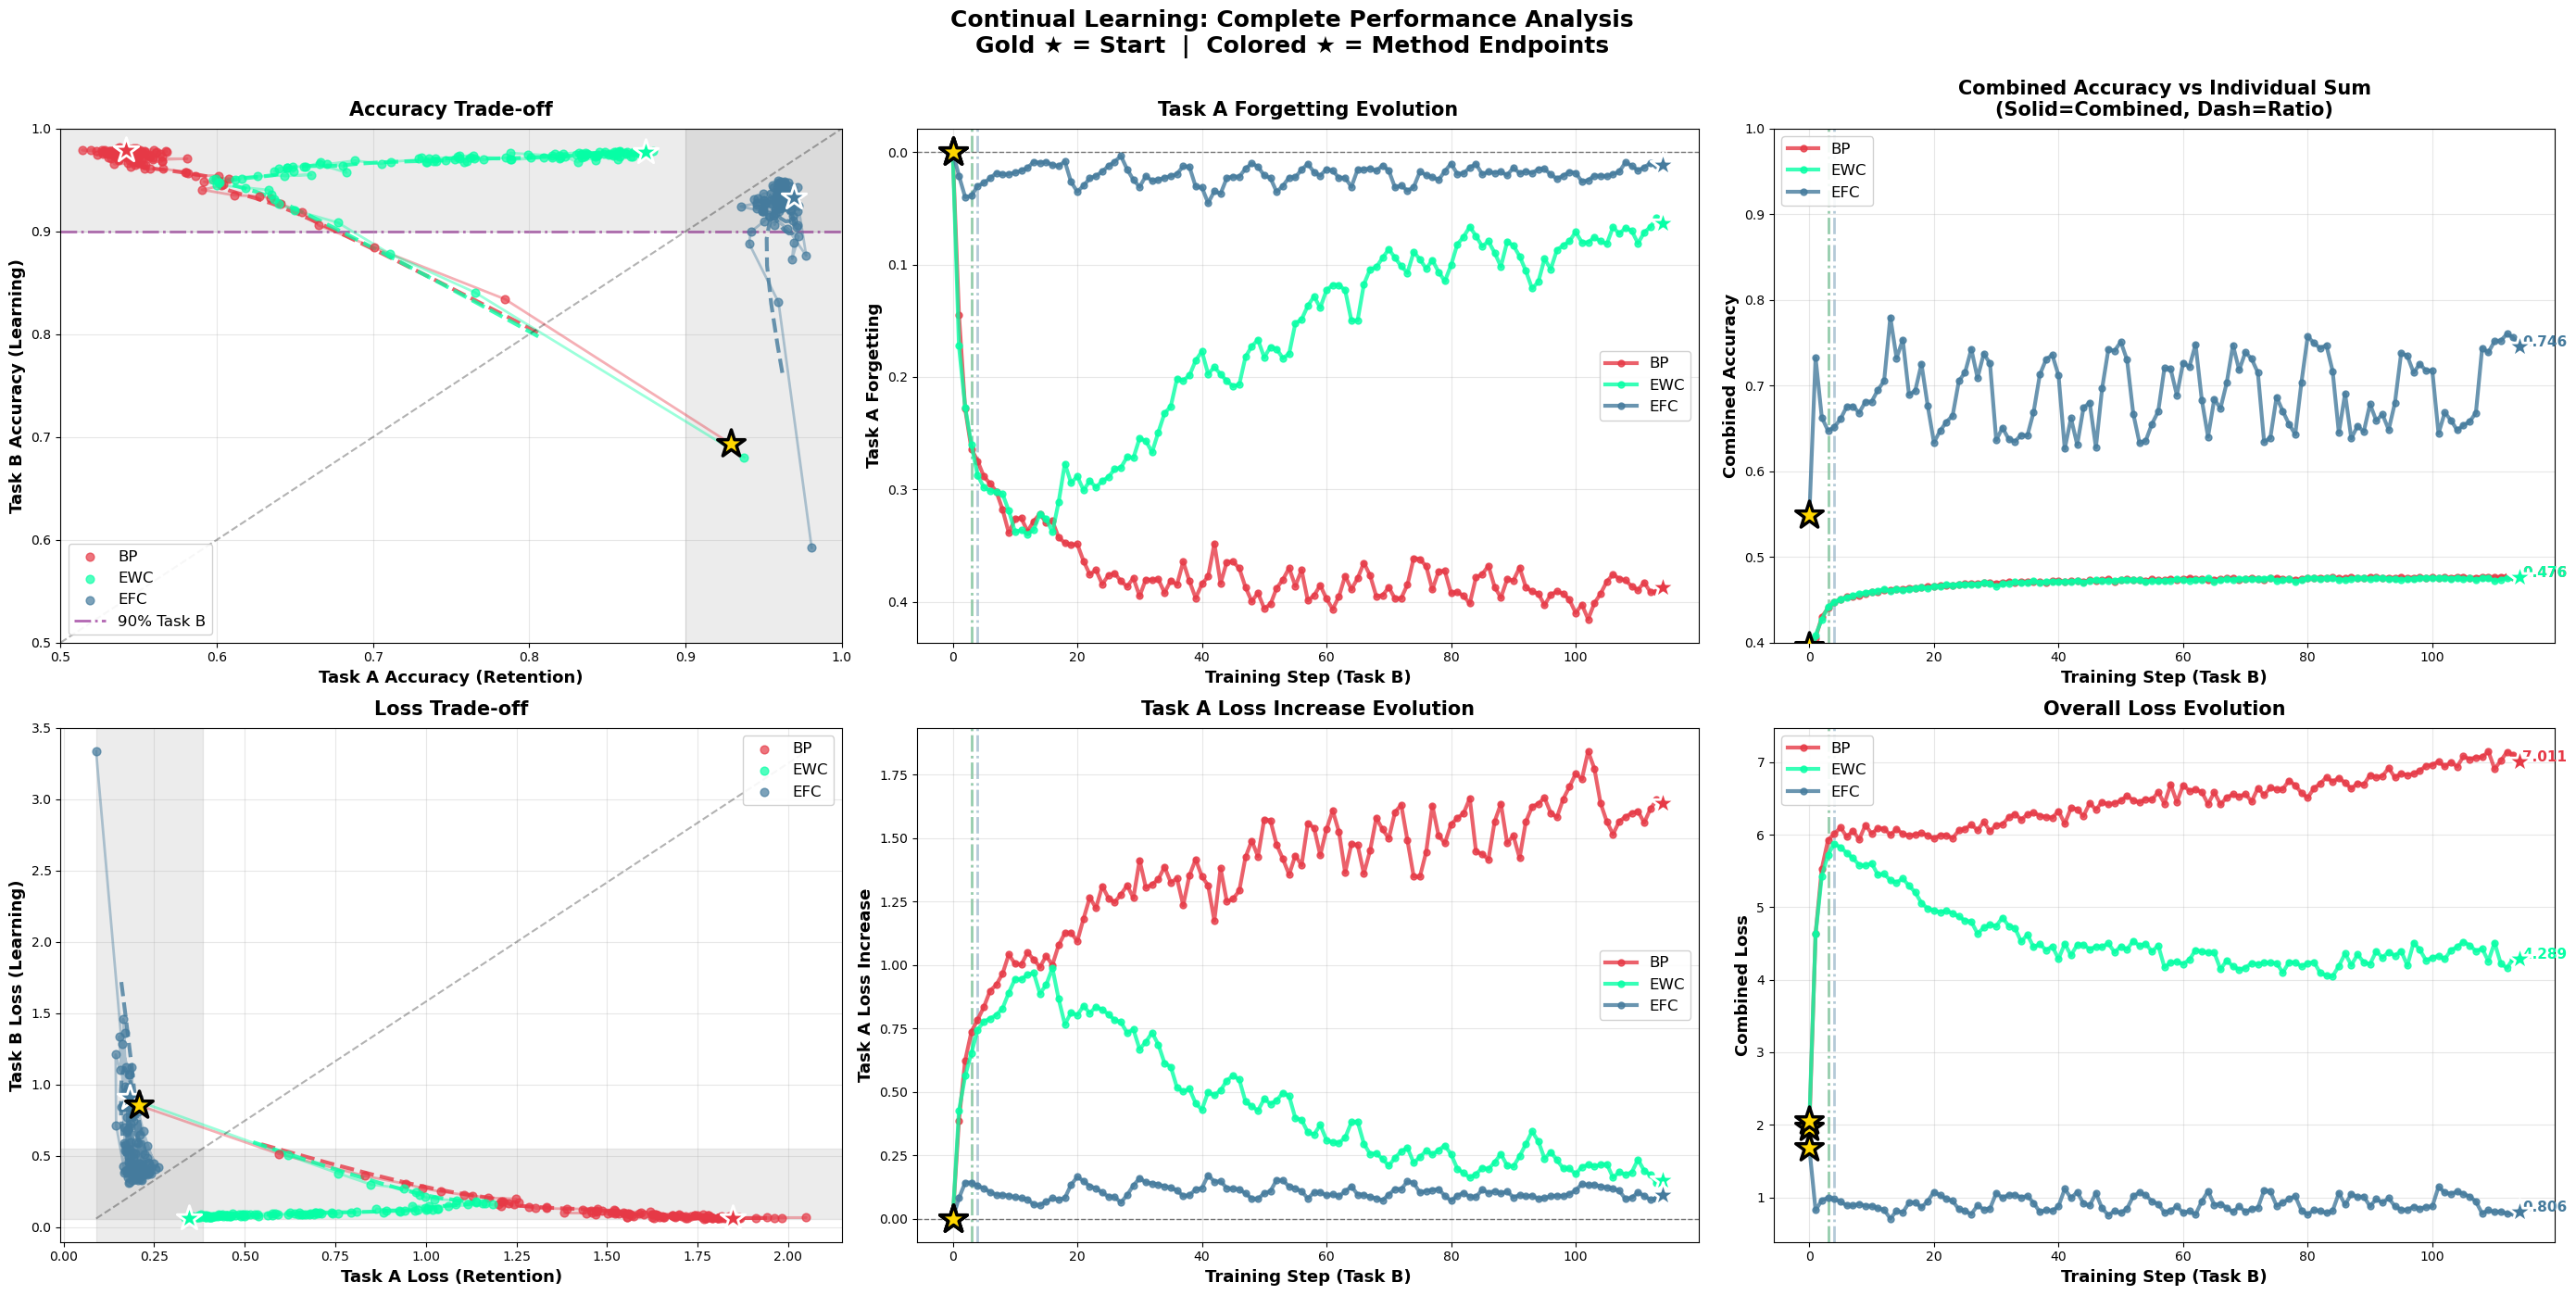


FINAL PERFORMANCE SUMMARY

BP:
  Task A Acc: 0.542 (Forgetting: 0.387)
  Combined Acc: 0.476
  Combined Loss: 7.011

EWC:
  Task A Acc: 0.874 (Forgetting: 0.063)
  Combined Acc: 0.476
  Combined Loss: 4.289

EFC:
  Task A Acc: 0.969 (Forgetting: 0.011)
  Combined Acc: 0.746
  Combined Loss: 0.806


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

methods = ['bp', 'ewc', 'ehc', 'efc']

# Extract data from your logs
trajectory_acc = {}
trajectory_loss = {}
for method in methods:
    trajectory_acc[method] = {
        'acc_A': acc_logs[method]['acc_A'],
        'acc_B': acc_logs[method]['acc_B'],
        'acc_C': acc_logs[method]['combined']
    }
    trajectory_loss[method] = {
        'loss_A': loss_logs[method]['loss_A'],
        'loss_B': loss_logs[method]['loss_B'],
        'loss_C': loss_logs[method]['combined']
    }

task_b_90_timepoints = {}
for method in methods:
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    idx = np.where(acc_B >= 0.9)[0]
    if len(idx) > 0:
        task_b_90_timepoints[method] = idx[0]  # First timepoint where acc_B >= 0.9
    else:
        task_b_90_timepoints[method] = None

# Create figure: 2 rows (accuracy/loss) × 3 columns
fig = plt.figure(figsize=(28, 14))

# More distinct colors
colors_method = {'bp': '#E63946', 'ewc': '#06FFA5', 'ehc': '#FFD166', 'efc': '#457B9D'}  # Red, Bright cyan, Yellow, Blue

# ============ PLOT 1: Task A vs Task B Accuracy Trade-off ============
ax1 = plt.subplot(2, 3, 1)

for method in methods:
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    
    # Plot trajectory as simple line
    ax1.plot(acc_A, acc_B, '-', color=colors_method[method], 
            linewidth=2, alpha=0.4)
    
    # Scatter points (small dots)
    ax1.scatter(acc_A, acc_B, s=40, color=colors_method[method], 
               alpha=0.7, label=method.upper(), zorder=3)
    
    # Add smooth trendline
    if len(acc_A) > 3:
        acc_A_smooth = gaussian_filter1d(acc_A, sigma=2)
        acc_B_smooth = gaussian_filter1d(acc_B, sigma=2)
        ax1.plot(acc_A_smooth, acc_B_smooth, '--', color=colors_method[method], 
                linewidth=3, alpha=0.8, zorder=2)
    
    # Mark endpoint with star
    ax1.scatter(acc_A[-1], acc_B[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)

# Mark common starting point
acc_A_start = trajectory_acc['bp']['acc_A'][0]
acc_B_start = trajectory_acc['bp']['acc_B'][0]
ax1.scatter(acc_A_start, acc_B_start, s=500, marker='*', 
           color='gold', edgecolor='black', linewidth=2.5, zorder=6)

# Add grey "ideal region" shading (overlapping gives darker)
ax1.axhspan(0.9, 1.0, alpha=0.15, color='grey')
ax1.axvspan(0.9, 1.0, alpha=0.15, color='grey')

# Diagonal reference line (no label)
ax1.plot([0.5, 1], [0.5, 1], 'k--', alpha=0.3, linewidth=1.5)

ax1.axhline(y=0.9, color='purple', linestyle='-.', linewidth=2, alpha=0.6, label='90% Task B', zorder=1)

ax1.set_xlabel('Task A Accuracy (Retention)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Task B Accuracy (Learning)', fontsize=13, fontweight='bold')
ax1.set_title('Accuracy Trade-off', fontsize=15, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12, loc='lower left', framealpha=0.9)
ax1.set_xlim([0.5, 1.0])
ax1.set_ylim([0.5, 1.0])

# ============ PLOT 2: Task A Forgetting over Time (Accuracy) ============
ax2 = plt.subplot(2, 3, 2)

for method in methods:
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    initial_acc_A = acc_A[0]
    forgetting = initial_acc_A - acc_A
    steps = np.arange(len(acc_A))
    
    # Mark starting point with star
    ax2.scatter(steps[0], forgetting[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax2.plot(steps, forgetting, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star
    ax2.scatter(steps[-1], forgetting[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax2.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Task A Forgetting', fontsize=13, fontweight='bold')
ax2.set_title('Task A Forgetting Evolution', fontsize=15, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12, loc='best', framealpha=0.9)
ax2.invert_yaxis()

# ============ PLOT 3: Combined Performance with Ratio Overlay ============
ax3 = plt.subplot(2, 3, 3)

for method in methods:
    acc_C = np.array(trajectory_acc[method]['acc_C'])
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    steps = np.arange(len(acc_C))
    
    # Calculate ratio: combined / (acc_A + acc_B)
    ratio = acc_C / (acc_A + acc_B + 1e-10)
    
    # Mark starting point with star
    ax3.scatter(steps[0], acc_C[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    # Plot combined accuracy (solid line, left y-axis)
    ax3.plot(steps, acc_C, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    
    # Mark endpoint with star and value
    ax3.scatter(steps[-1], acc_C[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    ax3.text(steps[-1]+0.5, acc_C[-1], f'{acc_C[-1]:.3f}', 
            fontsize=11, fontweight='bold', color=colors_method[method])

for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax3.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)


ax3.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Combined Accuracy', fontsize=13, fontweight='bold', color='black')
ax3.set_title('Combined Accuracy vs Individual Sum\n(Solid=Combined, Dash=Ratio)', 
             fontsize=15, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=12, loc='upper left', framealpha=0.9)
ax3.set_ylim([0.4, 1.0])


# ============ PLOT 4: Task A vs Task B Loss Trade-off ============
ax4 = plt.subplot(2, 3, 4)

for method in methods:
    loss_A = np.array(trajectory_loss[method]['loss_A'])
    loss_B = np.array(trajectory_loss[method]['loss_B'])
    
    # Plot trajectory
    ax4.plot(loss_A, loss_B, '-', color=colors_method[method], 
            linewidth=2, alpha=0.4)
    
    # Scatter points
    ax4.scatter(loss_A, loss_B, s=40, color=colors_method[method], 
               alpha=0.7, label=method.upper(), zorder=3)
    
    # Add smooth trendline
    if len(loss_A) > 3:
        loss_A_smooth = gaussian_filter1d(loss_A, sigma=2)
        loss_B_smooth = gaussian_filter1d(loss_B, sigma=2)
        ax4.plot(loss_A_smooth, loss_B_smooth, '--', color=colors_method[method], 
                linewidth=3, alpha=0.8, zorder=2)
    
    # Mark endpoint with star
    ax4.scatter(loss_A[-1], loss_B[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)

# Mark common starting point
loss_A_start = trajectory_loss['bp']['loss_A'][0]
loss_B_start = trajectory_loss['bp']['loss_B'][0]
ax4.scatter(loss_A_start, loss_B_start, s=500, marker='*', 
           color='gold', edgecolor='black', linewidth=2.5, zorder=6)

# Get reasonable axis limits
all_loss_A = np.concatenate([trajectory_loss[m]['loss_A'] for m in methods])
all_loss_B = np.concatenate([trajectory_loss[m]['loss_B'] for m in methods])
loss_A_min, loss_A_max = all_loss_A.min(), all_loss_A.max()
loss_B_min, loss_B_max = all_loss_B.min(), all_loss_B.max()

# Add grey "ideal region" shading (low loss = good, bottom-left corner)
ax4.axhspan(loss_B_min, loss_B_min + 0.15*(loss_B_max-loss_B_min), alpha=0.15, color='grey')
ax4.axvspan(loss_A_min, loss_A_min + 0.15*(loss_A_max-loss_A_min), alpha=0.15, color='grey')

# Diagonal reference line
ax4.plot([loss_A_min, loss_A_max], [loss_B_min, loss_B_max], 'k--', alpha=0.3, linewidth=1.5)

ax4.set_xlabel('Task A Loss (Retention)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Task B Loss (Learning)', fontsize=13, fontweight='bold')
ax4.set_title('Loss Trade-off', fontsize=15, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=12, loc='upper right', framealpha=0.9)

# ============ PLOT 5: Task A Loss Increase over Time ============
ax5 = plt.subplot(2, 3, 5)

for method in methods:
    loss_A = np.array(trajectory_loss[method]['loss_A'])
    initial_loss_A = loss_A[0]
    loss_increase = loss_A - initial_loss_A  # Increase = how much loss went up
    steps = np.arange(len(loss_A))
    
    # Mark starting point with star
    ax5.scatter(steps[0], loss_increase[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax5.plot(steps, loss_increase, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star
    ax5.scatter(steps[-1], loss_increase[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax5.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax5.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax5.set_ylabel('Task A Loss Increase', fontsize=13, fontweight='bold')
ax5.set_title('Task A Loss Increase Evolution', fontsize=15, fontweight='bold', pad=10)
ax5.grid(True, alpha=0.3)
ax5.legend(fontsize=12, loc='best', framealpha=0.9)

# ============ PLOT 6: Combined Loss over Time ============
ax6 = plt.subplot(2, 3, 6)

for method in methods:
    loss_C = np.array(trajectory_loss[method]['loss_C'])
    steps = np.arange(len(loss_C))
    
    # Mark starting point with star
    ax6.scatter(steps[0], loss_C[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax6.plot(steps, loss_C, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star and value
    ax6.scatter(steps[-1], loss_C[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    ax6.text(steps[-1]+0.5, loss_C[-1], f'{loss_C[-1]:.3f}', 
            fontsize=11, fontweight='bold', color=colors_method[method])
    
# Add vertical lines when Task B reaches 90%
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax6.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax6.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax6.set_ylabel('Combined Loss', fontsize=13, fontweight='bold')
ax6.set_title('Overall Loss Evolution', fontsize=15, fontweight='bold', pad=10)
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=12, loc='best', framealpha=0.9)


plt.suptitle('Continual Learning: Complete Performance Analysis\nGold ★ = Start  |  Colored ★ = Method Endpoints', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('figs/performance_analysis.svg', format='svg', bbox_inches='tight')
plt.savefig('figs/performance_analysis.eps', format='eps', bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
for method in methods:
    acc_A_final = trajectory_acc[method]['acc_A'][-1]
    acc_A_initial = trajectory_acc[method]['acc_A'][0]
    forgetting = acc_A_initial - acc_A_final
    acc_C_final = trajectory_acc[method]['acc_C'][-1]
    loss_C_final = trajectory_loss[method]['loss_C'][-1]
    
    print(f"\n{method.upper()}:")
    print(f"  Task A Acc: {acc_A_final:.3f} (Forgetting: {forgetting:.3f})")
    print(f"  Combined Acc: {acc_C_final:.3f}")
    print(f"  Combined Loss: {loss_C_final:.3f}")